1) Data Preprocessing and EDA

In [1]:
pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
print("✅ Train shape before cleaning:", train.shape)
print("✅ Test shape before cleaning:", test.shape)

✅ Train shape before cleaning: (136429, 14)
✅ Test shape before cleaning: (90954, 13)


In [5]:
# Data Cleaning
# Remove duplicate rows
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)


In [6]:
# Remove rows with missing values
train.dropna(inplace=True)
test.dropna(inplace=True)

In [7]:
print("✅ Train shape after cleaning:", train.shape)
print("✅ Test shape after cleaning:", test.shape)

✅ Train shape after cleaning: (136429, 14)
✅ Test shape after cleaning: (90954, 13)


C:\Users\ellic\AppData\Local\Temp\ipykernel_5572\2938876360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Machine failure", data=train, palette="coolwarm")


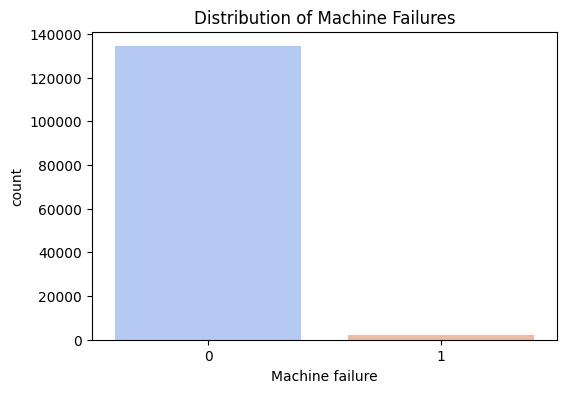

Machine failure counts:
 Machine failure
0    134281
1      2148
Name: count, dtype: int64


In [8]:
# Check target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Machine failure", data=train, palette="coolwarm")
plt.title("Distribution of Machine Failures")
plt.show()

failure_count=train["Machine failure"].value_counts()
print("Machine failure counts:\n", failure_count)

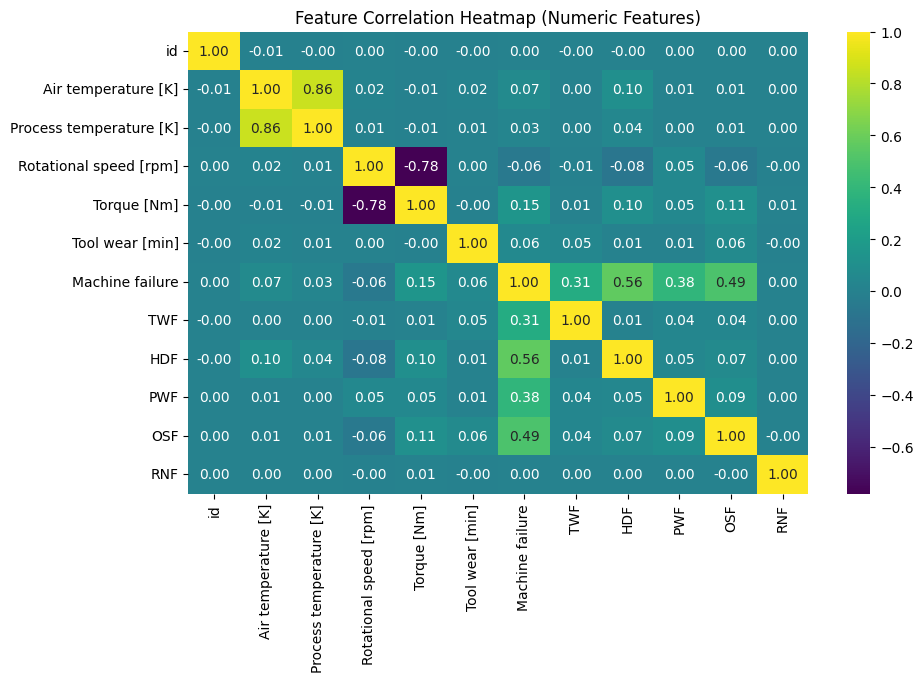

In [9]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(10,6))
numeric_df = train.select_dtypes(include=["int64", "float64"])  # keep only numbers
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Feature Correlation Heatmap (Numeric Features)")
plt.show()


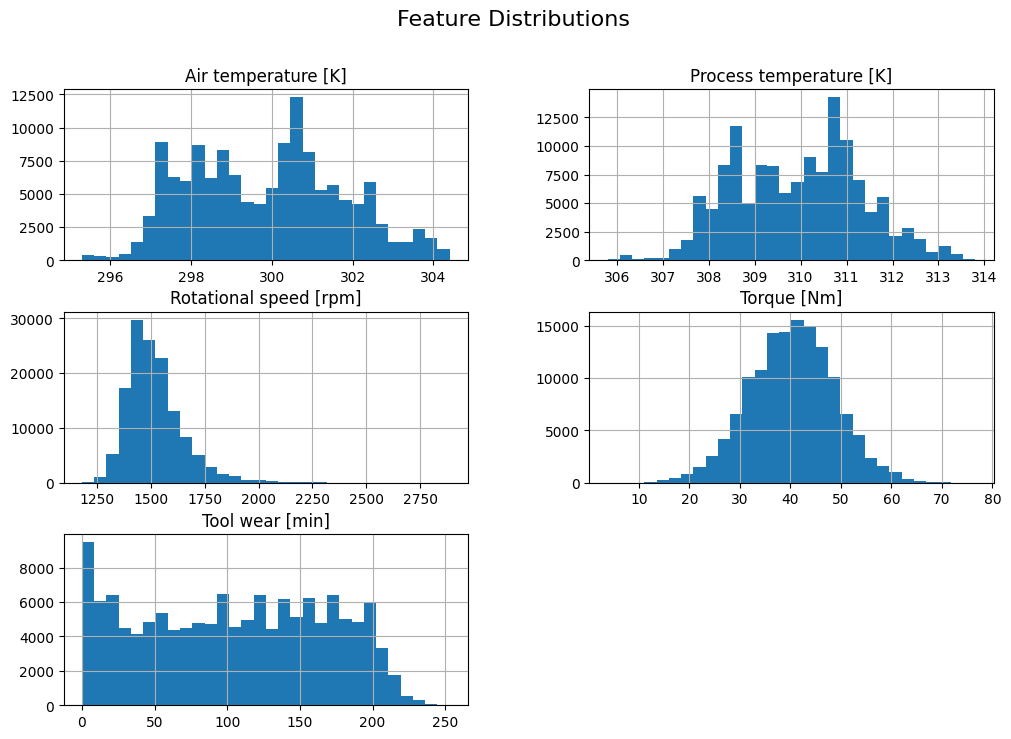

In [10]:
# feature distributions
numeric_cols = ["Air temperature [K]", "Process temperature [K]", 
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

train[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Feature Distributions", size=16)
plt.show()

2) Using 3-sigma rule to detect anomalies in sensor values.

In [11]:
import numpy as np

# 📌 Select numeric sensor columns
sensor_cols = ["Air temperature [K]", "Process temperature [K]", 
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

# 📌 Function to detect anomalies using 3-sigma rule
def detect_anomalies(df, cols):
    anomalies = {}
    for col in cols:
        mean = df[col].mean()
        std = df[col].std()
        lower, upper = mean - 3*std, mean + 3*std

        # Mark abnormal rows
        abnormal_rows = df[(df[col] < lower) | (df[col] > upper)]
        anomalies[col] = {
            "lower_bound": lower,
            "upper_bound": upper,
            "num_abnormal": len(abnormal_rows),
            "abnormal_indices": abnormal_rows.index.tolist()[:10]  # first 10 indices
        }
    return anomalies

# 📌 Detect anomalies in train set
sensor_anomalies = detect_anomalies(train, sensor_cols)

# 📌 Print results
for sensor, info in sensor_anomalies.items():
    print(f"\n🔎 {sensor}")
    print(f"  Range considered normal: {info['lower_bound']:.2f} – {info['upper_bound']:.2f}")
    print(f"  Abnormal readings found: {info['num_abnormal']}")
    print(f"  Example abnormal indices: {info['abnormal_indices']}")



🔎 Air temperature [K]
  Range considered normal: 294.28 – 305.45
  Abnormal readings found: 0
  Example abnormal indices: []

🔎 Process temperature [K]
  Range considered normal: 305.79 – 314.10
  Abnormal readings found: 0
  Example abnormal indices: []

🔎 Rotational speed [rpm]
  Range considered normal: 1104.12 – 1936.54
  Abnormal readings found: 1824
  Example abnormal indices: [103, 174, 227, 239, 244, 262, 363, 382, 387, 398]

🔎 Torque [Nm]
  Range considered normal: 14.84 – 65.86
  Abnormal readings found: 474
  Example abnormal indices: [745, 1044, 1673, 1796, 2249, 2381, 2577, 2673, 2708, 3154]

🔎 Tool wear [min]
  Range considered normal: -87.49 – 296.30
  Abnormal readings found: 0
  Example abnormal indices: []


3) Using Isolation forest model to detect anomalies in sensor values.

In [12]:
from sklearn.ensemble import IsolationForest

# 📌 Select numeric sensor columns
sensor_cols = ["Air temperature [K]", "Process temperature [K]", 
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

# 📌 Function to detect anomalies using Isolation Forest
def detect_anomalies_iforest(df, cols, contamination=0.01):
    anomalies = {}
    for col in cols:
        # Reshape since IsolationForest expects 2D input
        X = df[[col]].values  

        # Train Isolation Forest
        iso = IsolationForest(contamination=contamination, random_state=42)
        preds = iso.fit_predict(X)

        # -1 = anomaly, 1 = normal
        abnormal_indices = df.index[preds == -1].tolist()

        anomalies[col] = {
            "num_abnormal": len(abnormal_indices),
            "abnormal_indices": abnormal_indices[:10],  # first 10 indices
        }
    return anomalies

# 📌 Detect anomalies in train set
sensor_anomalies_iforest = detect_anomalies_iforest(train, sensor_cols, contamination=0.02)

# 📌 Print results
for sensor, info in sensor_anomalies_iforest.items():
    print(f"\n🔎 {sensor}")
    print(f"  Abnormal readings found: {info['num_abnormal']}")
    print(f"  Example abnormal indices: {info['abnormal_indices']}")



🔎 Air temperature [K]
  Abnormal readings found: 2631
  Example abnormal indices: [138, 166, 178, 203, 230, 259, 284, 419, 520, 523]

🔎 Process temperature [K]
  Abnormal readings found: 2387
  Example abnormal indices: [138, 166, 178, 203, 259, 284, 403, 520, 523, 656]

🔎 Rotational speed [rpm]
  Abnormal readings found: 2708
  Example abnormal indices: [103, 174, 227, 236, 239, 244, 262, 271, 363, 373]

🔎 Torque [Nm]
  Abnormal readings found: 2669
  Example abnormal indices: [103, 174, 236, 237, 244, 262, 382, 395, 409, 442]

🔎 Tool wear [min]
  Abnormal readings found: 2559
  Example abnormal indices: [162, 169, 222, 246, 261, 385, 451, 507, 608, 682]


4) Using Linear Regression Model to detect anomalies in sensor values.

In [13]:
pip install scikit-learn pandas numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 📌 Features = sensor columns
sensor_cols = ["Air temperature [K]", "Process temperature [K]", 
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

X = train[sensor_cols].values
y = train["Machine failure"].values

# 📌 Split into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 📌 Standardize sensor values (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 📌 Train Logistic Regression
log_reg = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 📌 Predictions
y_pred = log_reg.predict(X_val_scaled)

# 📌 Evaluation
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_val, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_val, y_pred, zero_division=0))


Accuracy : 0.7870702924576706
Precision: 0.0513675783855904
Recall   : 0.7162790697674418
F1 Score : 0.09586056644880174

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.79      0.88     26856
           1       0.05      0.72      0.10       430

    accuracy                           0.79     27286
   macro avg       0.52      0.75      0.49     27286
weighted avg       0.98      0.79      0.87     27286



Inference: We found out that using linear regression is best for finding anomalies in a supervised dataset. Therefore we implement linear regression to validate accuracy and then use the test dataset to predict machine failure.

Generating predictions based on train and test data.

In [16]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# -----------------------------
# 0. Feature selection
# -----------------------------
sensor_cols = ["Air temperature [K]", "Process temperature [K]",
               "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

X = train[sensor_cols]                  # ✅ keep as DataFrame
y = train["Machine failure"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test = test[sensor_cols]              # Also DataFrame

# -----------------------------
# 1. Separate categorical and numeric columns
# -----------------------------
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# -----------------------------
# 2. Build pipeline with Logistic Regression
# -----------------------------
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# -----------------------------
# 3. Train/Validate
# -----------------------------
clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# -----------------------------
# 4. Test Predictions
# -----------------------------
test_proba = clf.predict_proba(X_test)[:, 1]

# Load sample submission
sample_submission = pd.read_csv("sample_submission.csv")
submission = sample_submission.copy()
submission["Machine failure"] = test_proba
submission.to_csv("submission.csv", index=False)

print("✅ Submission file created: submission.csv")


Validation Accuracy: 0.7870702924576706

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.79      0.88     26856
           1       0.05      0.72      0.10       430

    accuracy                           0.79     27286
   macro avg       0.52      0.75      0.49     27286
weighted avg       0.98      0.79      0.87     27286

✅ Submission file created: submission.csv
